In [56]:
import matplotlib.pyplot
import pandas
from pathlib import Path

In [62]:
def parse_results() -> pandas.DataFrame:
    rows = []

    for path in Path("results/").iterdir():
        if path.name == '.gitkeep':
            continue

        experiment : str = ""

        if "without-ebpf-probe" in path.name:
            experiment = "without-ebpf-probe"
        else:
            experiment = "with-ebpf-probe"

        with open(path, mode='r') as log_file:
            raw_data = log_file.read().splitlines(keepends=True)

            actual_queries_per_second = float(raw_data[-7].split()[3])

            rows.append({
                'experiment':  experiment,
                'qps':         actual_queries_per_second,
                'read_p99':    float(raw_data[-11].split()[-1]),
                'update_p99':  float(raw_data[-10].split()[-1]),
                'read_p95':    float(raw_data[-11].split()[-2]),
                'update_p95':  float(raw_data[-10].split()[-2]),
            })
    
    return pandas.DataFrame(rows)

def plot_results() -> None:
    data_frame = parse_results()

    without_ebpf_probe_read_p99 = data_frame[data_frame['experiment'] == 'without-ebpf-probe']['read_p99']
    with_ebpf_probe_read_p99    = data_frame[data_frame['experiment'] == 'with-ebpf-probe']['read_p99']

    matplotlib.pyplot.ylabel("read_p99")
    matplotlib.pyplot.title("Average read_p99 across 10 runs (800K QPS, --network host)")
    matplotlib.pyplot.boxplot([without_ebpf_probe_read_p99, with_ebpf_probe_read_p99])
    matplotlib.pyplot.xticks([1, 2], ["without eBPF probe", "with eBPF probe"])

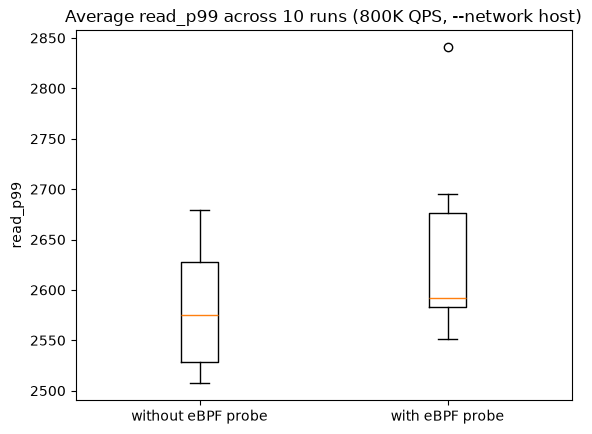

In [63]:
plot_results()